In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import pickle
from sklearn.model_selection import cross_val_score


In [44]:
data=pd.read_csv('dataset.csv')

In [45]:
data.head()

,gestational_week,pain,contractions,bleeding,fetal_movement,swelling,vision,risk
0,32,2,3,1,1,0,0,Monitor
1,34,3,1,1,0,1,0,Emergency
2,37,1,2,0,1,0,0,Monitor
3,40,3,1,1,1,0,0,Emergency
4,40,3,1,1,1,1,0,Emergency


In [47]:
data.isnull().sum()

gestational_week    0
pain                0
contractions        0
bleeding            0
fetal_movement      0
swelling            0
vision              0
risk                0
dtype: int64

In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   gestational_week  5000 non-null   int64 
 1   pain              5000 non-null   int64 
 2   contractions      5000 non-null   int64 
 3   bleeding          5000 non-null   int64 
 4   fetal_movement    5000 non-null   int64 
 5   swelling          5000 non-null   int64 
 6   vision            5000 non-null   int64 
 7   risk              5000 non-null   object
dtypes: int64(7), object(1)
memory usage: 312.6+ KB


In [49]:
data.describe()

,gestational_week,pain,contractions,bleeding,fetal_movement,swelling,vision
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,35.962800,2.007200,1.485000,0.504800,0.496400,0.498400,0.500800
std,2.580843,0.809987,1.119118,0.500027,0.500037,0.500047,0.500049
min,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,36.000000,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000
75%,38.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000
max,40.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


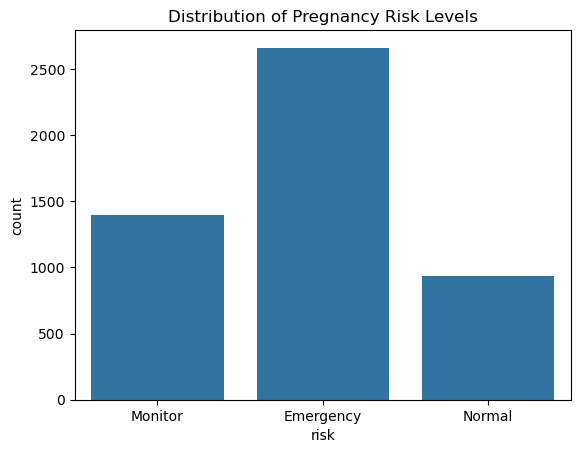

In [50]:
sns.countplot(x="risk", data=data)
plt.title("Distribution of Pregnancy Risk Levels")
plt.show()

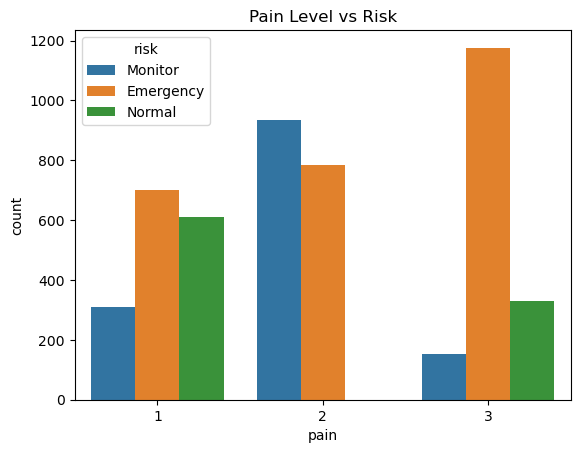

In [51]:
sns.countplot(x="pain", hue="risk", data=data)
plt.title("Pain Level vs Risk")
plt.show()

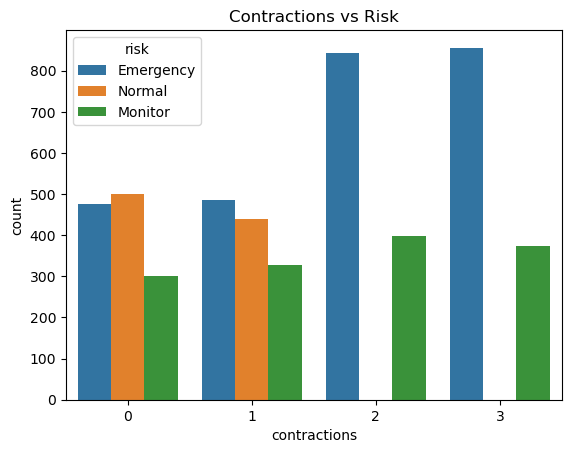

In [52]:
sns.countplot(x="contractions", hue="risk", data=data)
plt.title("Contractions vs Risk")
plt.show()

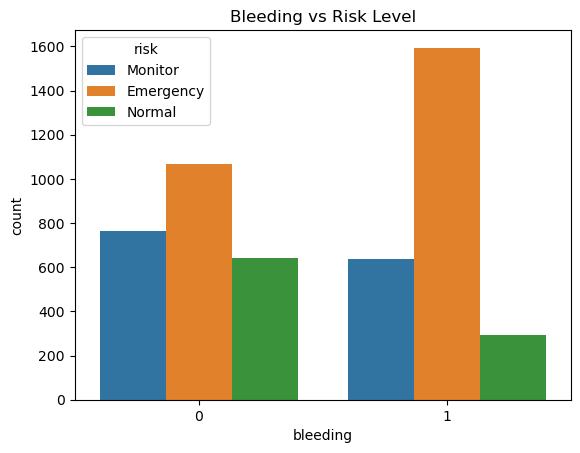

In [53]:
sns.countplot(x="bleeding", hue="risk", data=data)
plt.title("Bleeding vs Risk Level")
plt.show()

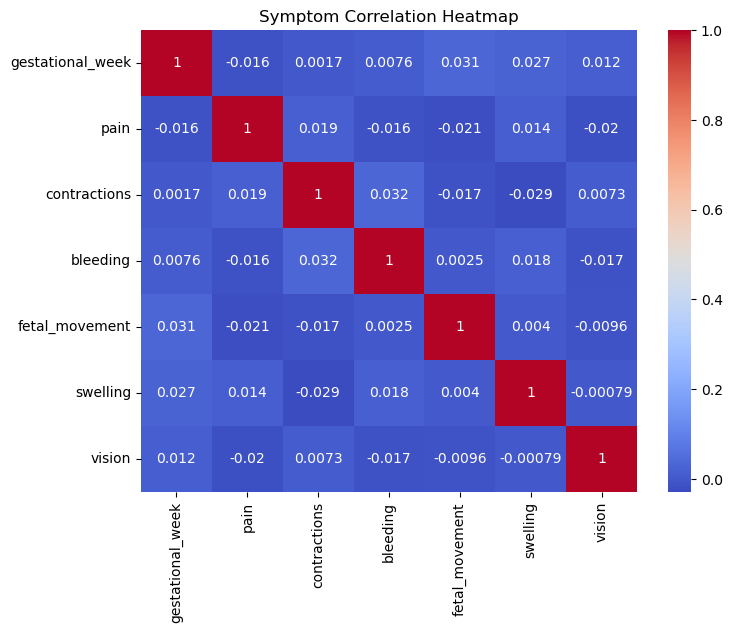

In [54]:
plt.figure(figsize=(8,6))

corr = data.drop("risk", axis=1).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Symptom Correlation Heatmap")
plt.show()

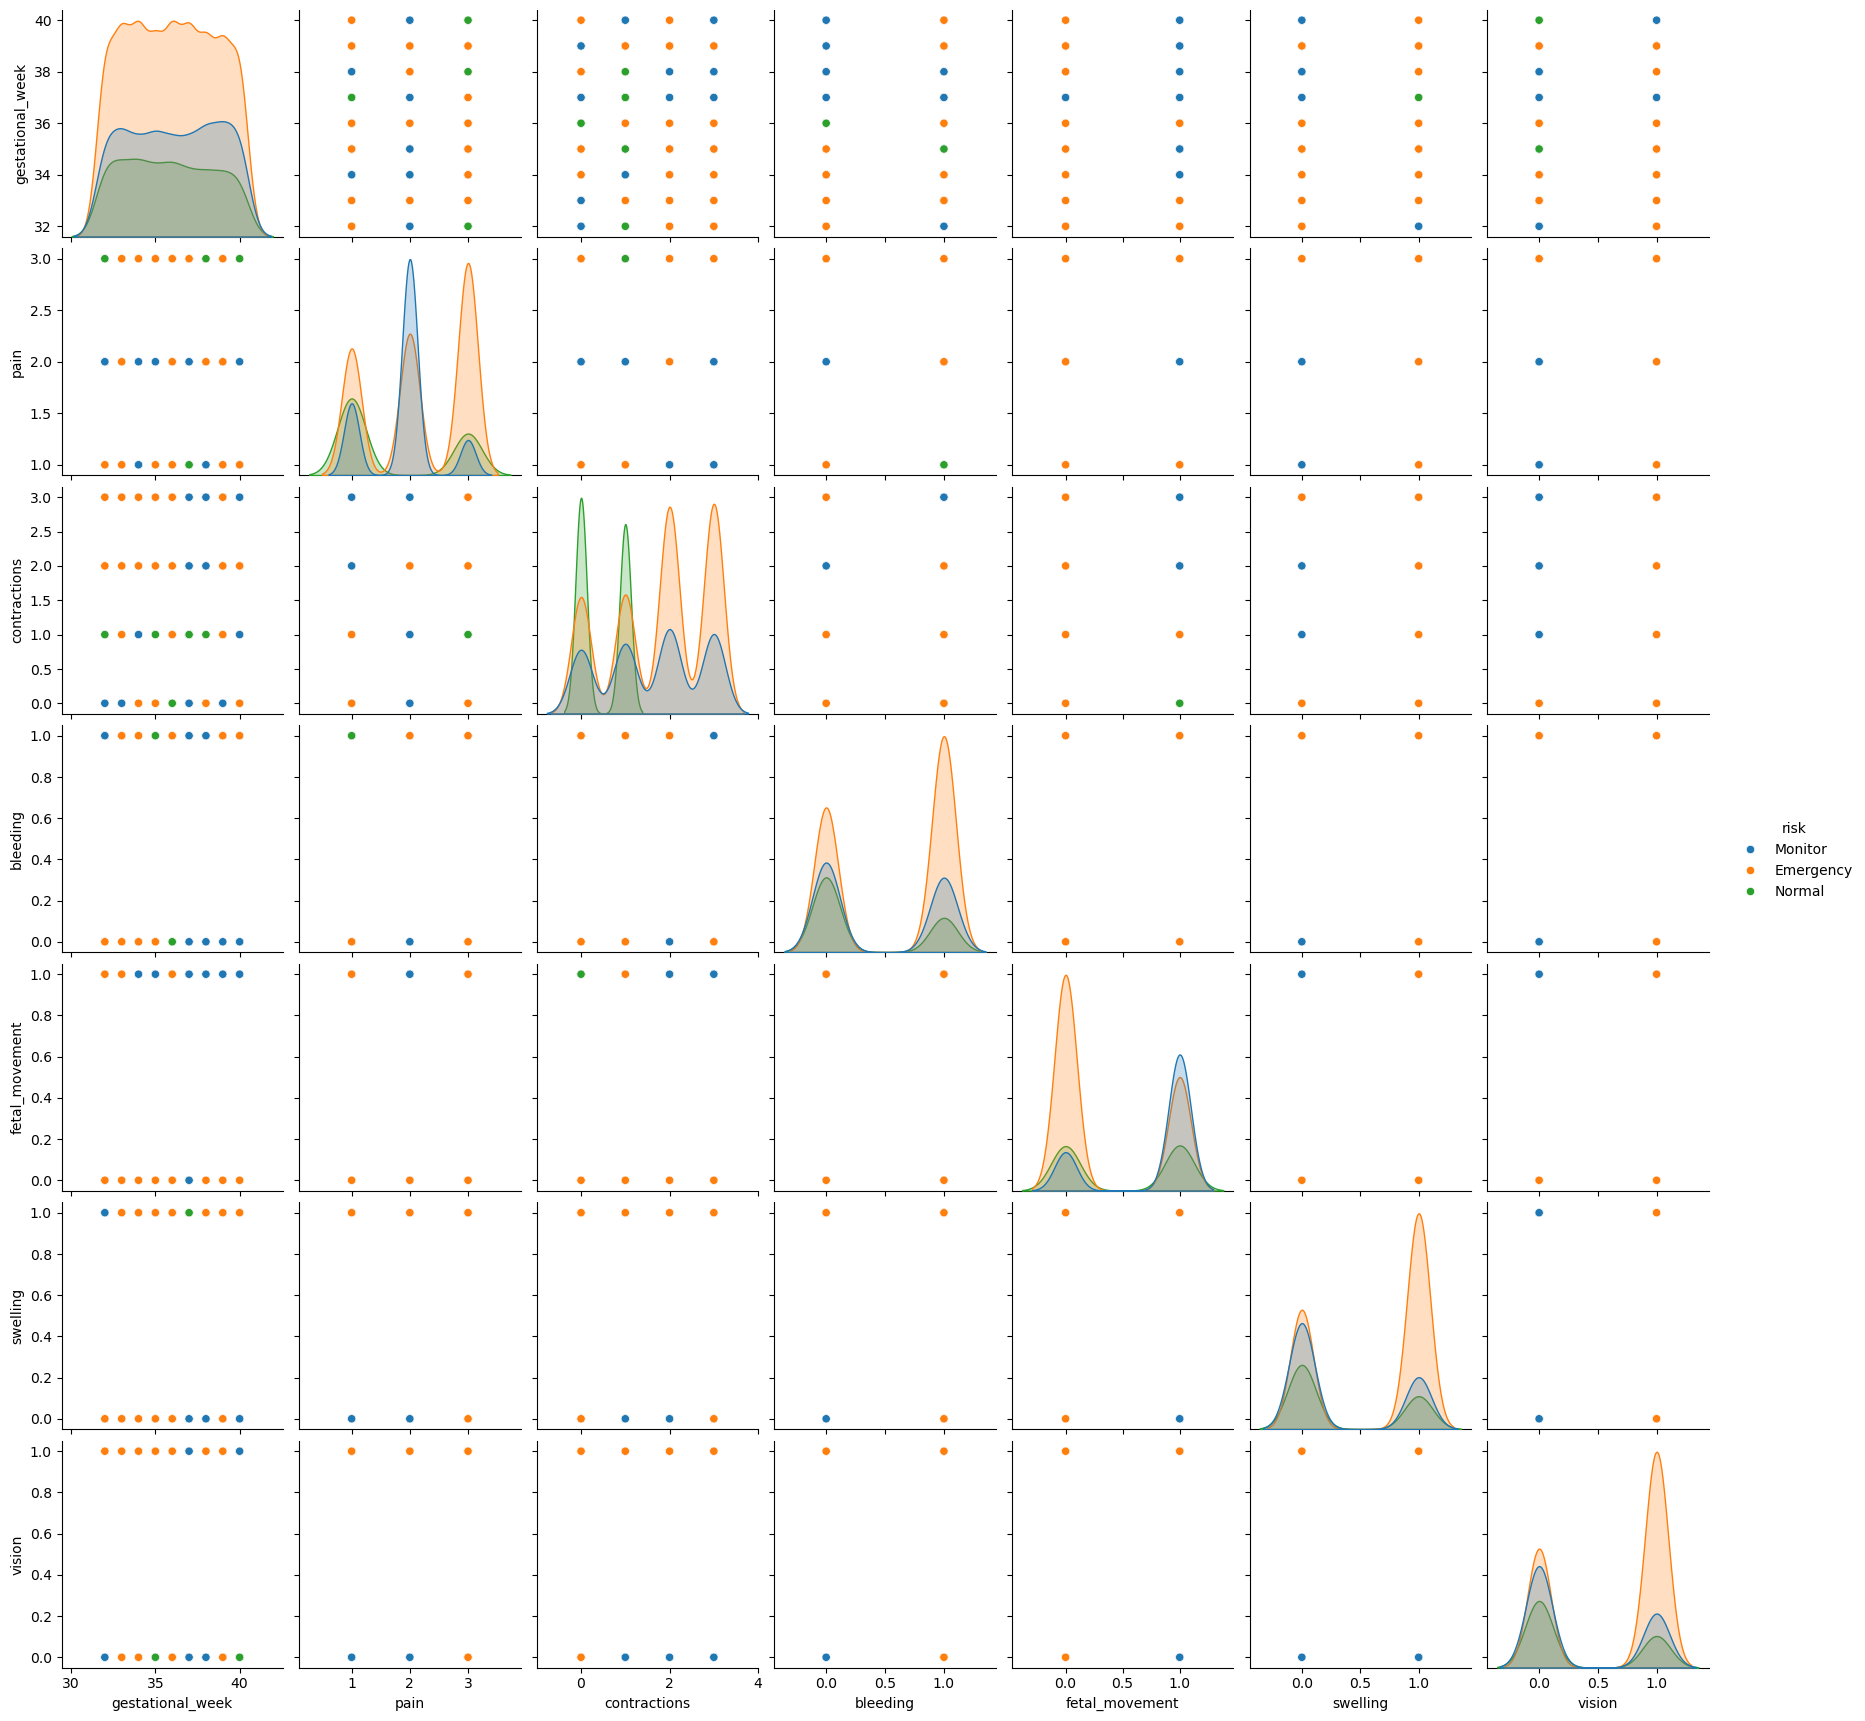

In [55]:
sns.pairplot(data, hue="risk")
plt.show()

In [56]:
x=data.drop(columns=['risk'])

In [57]:
y=data['risk']

In [58]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [59]:
model = DecisionTreeClassifier()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)


In [60]:
acc = accuracy_score(y_test, y_pred)


In [61]:
confusion_matrix(y_test,y_pred)

array([[528,   0,   0],
       [  0, 281,   0],
       [  0,   0, 191]])

In [62]:

scores = cross_val_score(model, x, y, cv=5)

print(scores)
print(scores.mean())

[1. 1. 1. 1. 1.]
1.0


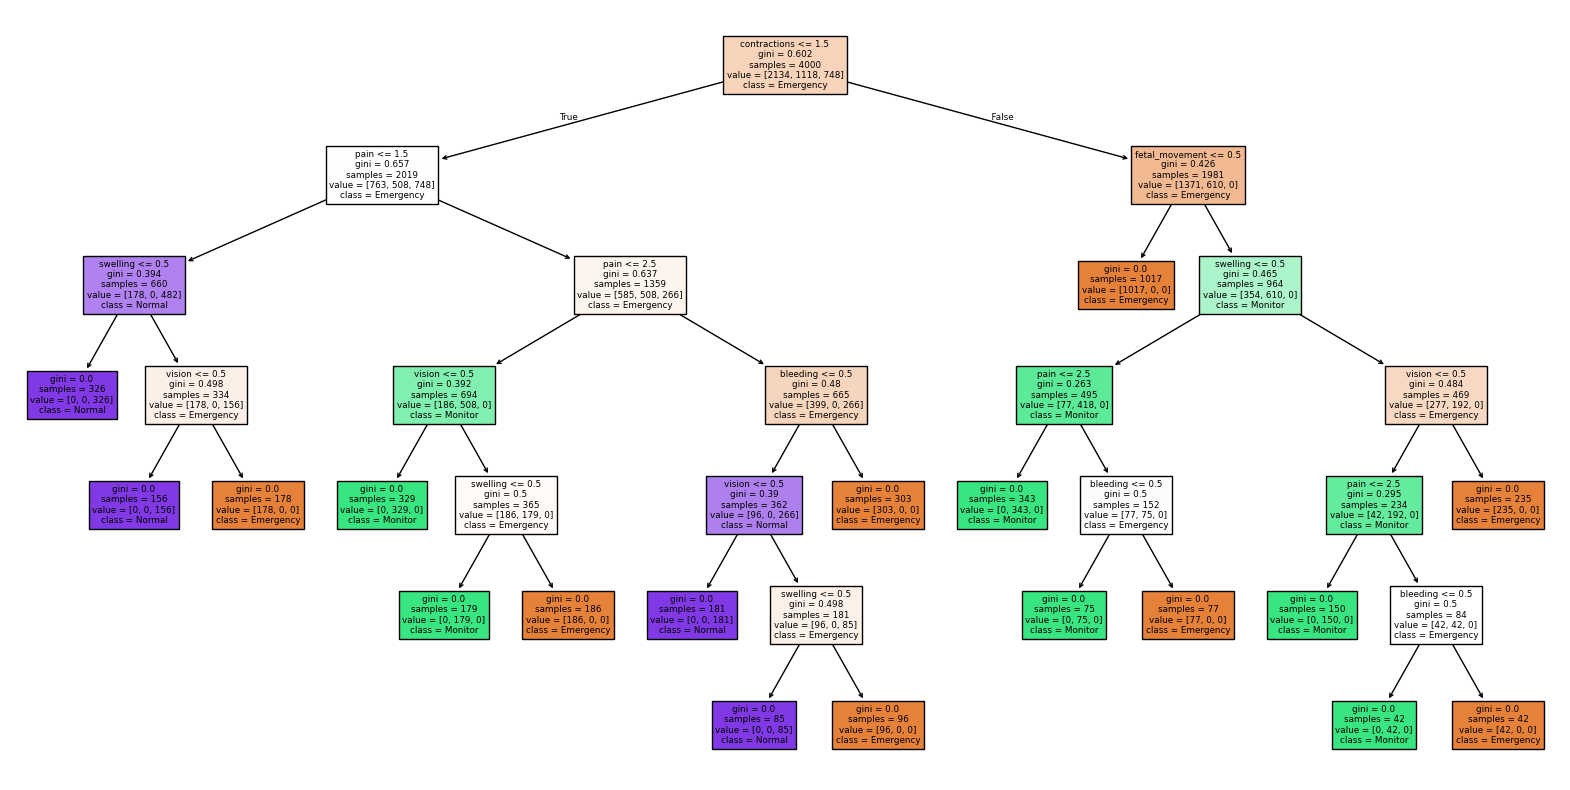

In [63]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(model, feature_names=x.columns, class_names=model.classes_, filled=True)
plt.show()

In [64]:
pickle.dump(model, open("pregnancy_model.pkl", "wb"))

print("Model saved")

Model saved
